In [102]:
# Wavefunction generation
from pyscf import mcscf, fci, lib 
from pyscf import gto, scf, tools, dft
import api as pyq 
import importlib
import os
import h5py
import pandas as pd
import pdb
import pyscf
import numpy as np
import pyqmc
import scipy
import copy
import gpu
import matplotlib.pyplot as plt
from pyscf.scf.hf import dump_scf_summary
from concurrent.futures import ProcessPoolExecutor
from pyscf.scf.chkfile import dump_scf
print(pyq.__file__)
print(pyscf.__file__)

/Users/ksu/Documents/GitHub/pyqmc/pyqmc/api.py
/Users/ksu/Software/anaconda3/lib/python3.11/site-packages/pyscf/__init__.py


In [103]:
# Wavefunction generation
from scf_runs import run_lda_he, run_casci
scf_chkfile, _, mf_lda = run_lda_he()
ci_chkfile, mcc, opt_chkfile, vmc_chkfile = run_casci(scf_chkfile, nroots=2, ncas = 1)

He atom neutral LDA spin=0
LDA
converged SCF energy = -2.72349509516031  <S^2> = -8.8817842e-16  2S+1 = 1
CASCI nelecas up/down (1, 1)

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -2.85769718299365  E(CI) = -2.85769718299365  S^2 = 0.0000000
Available output from CASCI: <KeysViewHDF5 ['ci', 'fci', 'mc_mo_energy', 'mf_mo_energy', 'mo_coeff', 'mo_occ', 'ncas', 'ncore', 'nelecas']>


In [104]:
import importlib, bosonrecipes, mc, bosonslater
modules = [bosonrecipes, mc, bosonslater]
for m in modules:
    importlib.reload(m)

for fname in [opt_chkfile]:
    if os.path.isfile(fname):
        os.remove(fname)
jastrow_kws = {"ion_cusp":False, "na":0}
wf, df = bosonrecipes.ABOPTIMIZE(
                        scf_chkfile, 
                         opt_chkfile,
                         nconfig=1000, 
                          max_iterations=5,
                         ci_checkfile=ci_chkfile,
                         jastrow_kws = jastrow_kws,
                         # det_emax = 1,
                         verbose = True,)

Used # of determinants 1
Using spherical guess
starting warmup
finished warmup
Pgrad acc type:  <class 'boson_stochastic_reconfiguration.BosonStochasticReconfiguration'>
Pgrad enacc type:  <class 'bosonaccumulators.ABQMCEnergyAccumulator'>
Pgrad transform type:  <class 'accumulators.LinearTransform'>
0 params [0. 0. 0. 0. 0. 0. 0. 0. 0.]
--0.015148383438695795 -0.023760738136926925 0.6949286595748889 3.1965062032732847 -0.9255035703015271 -1.0338438671982784 -4.24987856509823 0.0 -2.64882696217077
--0.017642119559638608 -0.025838537076399312 0.731761459879952 3.3361664357665033 -0.9861044521403977 -1.0338438671982784 -4.58623158010754 0.0 -2.695625047580469
--0.0209193599545576 -0.028361174046495335 0.7721721237914502 3.4475910153967257 -1.0358626188514264 -1.0338438671982784 -4.8985672970323835 0.0 -2.722680673953181
--0.023718424482384946 -0.03179972303192784 0.7983398701523999 3.5584934090873657 -1.0846543967830198 -1.0338438671982784 -5.160481444500696 0.0 -2.7648611568645376
--0.0

In [105]:
from bosonrecipes import initialize_boson_qmc_objects
from recipes import initialize_qmc_objects
from copy import deepcopy

wfb, configs, accb = initialize_boson_qmc_objects(
    scf_chkfile,
    nconfig         = 1000,
    ci_checkfile    = ci_chkfile,
    load_parameters = opt_chkfile,
    jastrow_kws     = jastrow_kws,
    slater_kws      = None,
    accumulators    = None,
)

wfs, _, accs = initialize_qmc_objects(
    scf_chkfile,
    nconfig         = 1000,
    ci_checkfile    = ci_chkfile,
    load_parameters = opt_chkfile,
    jastrow_kws     = jastrow_kws,
    slater_kws      = None,
    accumulators    = None,
)

cc = copy.deepcopy(configs)
_ = wfb.recompute(configs)
_ = wfs.recompute(configs)

Used # of determinants 1
Using spherical guess


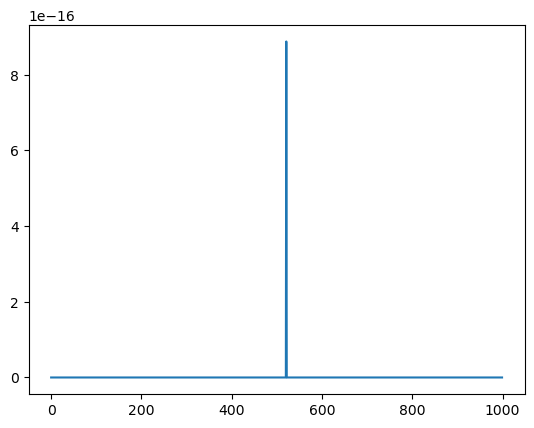

In [106]:
plt.plot(wfb.value()[1]-wfs.value()[1])

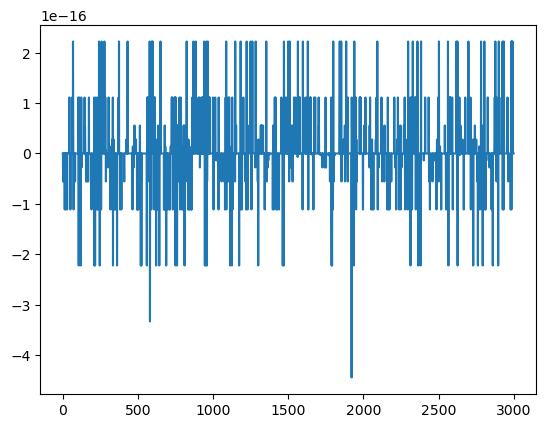

In [107]:
e = 0
plt.plot(wfb.gradient(e, configs.electron(e)).flatten()-wfs.gradient(e, configs.electron(e)).flatten())

In [108]:
# DMC 
import importlib, dmc
modules = [dmc]

for m in modules:
    importlib.reload(m)
    
from dmc import rundmc
configs = copy.deepcopy(cc)
# print(configs.configs[1])
dfs, _, ws = rundmc(wfs, configs, nblocks = 1, nsteps_per_block = 1, accumulators=accs, vmc_warmup=0, verbose = True)
# print(configs.configs[1])
dfs

blockoffset 0 >= nblocks 0; no steps will be run.
vmc done
eref start -2.539097090625313 esigma 0.39018350129787455
0 grad -0.5662755300700336
ratio 0 [1.00199026 0.99585768 0.99724978 1.00598594 0.99956408 0.99979507
 0.99948915 1.00054829 0.99946265 0.99955331]
1 grad -0.5317087681964319
ratio 1 [0.99987713 0.99850216 0.99929228 1.00310984 0.9991321  1.00151551
 1.00084834 1.00099396 0.99998654 1.00093102]
energy -2.5450777322097613 e_trial -2.5451071988168787 e_est -2.5450777322097613 sigma(w) 0.003897846674474928
{'max branches': 1, 'Number of walkers killed': 0}


{'energyke': array([0.13216645]),
 'energyee': array([0.57196153]),
 'energyei': array([-3.24920571]),
 'energyecp': array([0.]),
 'energygrad2': array([4.39797468]),
 'energytotal': array([-2.54507773]),
 'weight': array([1.00002947]),
 'acceptance': array([1.]),
 'tmove_acceptance': array([0.]),
 'e_trial': array([-2.53909709]),
 'e_est': array([-2.53909709]),
 'block': array([0]),
 'esigma': array([0.3901835]),
 'tstep': array([0.01]),
 'weight_std': array([0.00389785]),
 'nsteps_per_block': array([1]),
 'max branches': array([1]),
 'Number of walkers killed': array([0])}

In [109]:
# ABDMC 
import importlib, bosondmc
modules = [bosondmc]

for m in modules:
    importlib.reload(m)
    
from bosondmc import rundmc as brundmc 
configs = copy.deepcopy(cc)
# print(configs.configs[1])
dfb, _, wb = brundmc(wfs, configs, nblocks = 1, nsteps_per_block = 1, accumulators=accs, vmc_warmup=0, verbose=True)
# print(configs.configs[1])
dfb

blockoffset 0 >= nblocks 0; no steps will be run.
vmc done
eref start -2.539097090625313 esigma 0.39018350129787455
0 grad -0.5662755300700336
[[-0.20213842 -0.50415446  0.96452751]
 [ 0.80488334  0.93884917  1.01608399]]
ratio 0 [1.00199026 0.99585768 0.99724978 1.00598594 0.99956408 0.99979507
 0.99948915 1.00054829 0.99946265 0.99955331]
1 grad -0.5317087681964318
[[-0.20213842 -0.50415446  0.96452751]
 [ 0.96019384  0.86939303  0.95414039]]
ratio 1 [0.99987713 0.99850216 0.99929228 1.00310984 0.9991321  1.00151551
 1.00084834 1.00099396 0.99998654 1.00093102]
energy -2.5450777322097613 e_trial -2.5451071988168787 e_est -2.5450777322097613 sigma(w) 0.003897846674474928
{'max branches': 1, 'Number of walkers killed': 0}


{'energyke': array([0.13216645]),
 'energyee': array([0.57196153]),
 'energyei': array([-3.24920571]),
 'energyecp': array([0.]),
 'energygrad2': array([4.39797468]),
 'energytotal': array([-2.54507773]),
 'weight': array([1.00002947]),
 'acceptance': array([1.]),
 'e_trial': array([-2.53909709]),
 'e_est': array([-2.53909709]),
 'block': array([0]),
 'esigma': array([0.3901835]),
 'tstep': array([0.01]),
 'weight_std': array([0.00389785]),
 'nsteps_per_block': array([1]),
 'max branches': array([1]),
 'Number of walkers killed': array([0])}